# EEG Reward Learning Replication — Analysis Notebook
**Replication of Hassall et al. (2022) | Probabilistic Reward Learning Task**

This notebook implements our full preprocessing and analysis pipeline in five sequential stages:

| Stage | Description |
|---|---|
| 1 | Library Imports & Configuration |
| 2 | Data Loading & Inspection |
| 3 | Data Cleaning (Filtering, ICA, Referencing, Epoching) |
| 4 | Data Sanity Checks |
| 5 | Data Analysis & Visualisation |

---

## Stage 1 — Library Imports & Configuration

We begin by installing MNE (if not already available) and importing all required libraries. Global configuration variables — file paths, condition mappings, filter cutoffs, and analysis parameters — are defined here once so that they propagate consistently through every subsequent stage.

In [2]:
# Install MNE if not already available in the environment
# %pip install mne  # Uncomment if running for the first time

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

# ── Global Paths ──────────────────────────────────────────────────────────────
BIDS_ROOT = Path(".")  # Folder containing sub-XX directories

# ── Condition Mapping (event code → condition label) ─────────────────────────
# 20-series codes = Win feedback; 30-series codes = Loss feedback
# Win triggers (Stimulus/S 21 – S 26) and Loss triggers (Stimulus/S 31 – S 36)
# are the fruit-feedback events we time-lock our epochs to.
WIN_TRIGGERS  = [f'Stimulus/S {i}' for i in range(21, 27)]  # S21–S26
LOSS_TRIGGERS = [f'Stimulus/S {i}' for i in range(31, 37)]  # S31–S36

# Condition map for the contextual (task × cue) analysis
COND_MAP = {
    "Low-Low Win":   6,  "Low-Low Loss":   7,
    "Mid-Low Win":  16,  "Mid-Low Loss":  17,
    "Mid-High Win": 26,  "Mid-High Loss": 27,
    "High-High Win":36,  "High-High Loss":37,
}
DIFF_PAIRS = {
    "Low Task, Low Cue":  ("Low-Low Win",  "Low-Low Loss"),
    "Mid Task, Low Cue":  ("Mid-Low Win",  "Mid-Low Loss"),
    "Mid Task, High Cue": ("Mid-High Win", "Mid-High Loss"),
    "High Task, High Cue":("High-High Win","High-High Loss"),
}

# ── Filter & Epoch Parameters ─────────────────────────────────────────────────
L_FREQ_ERP  = 0.1   # High-pass for ERP track (preserves slow RewP morphology)
L_FREQ_ICA  = 1.0   # High-pass for ICA track (flatter baseline → better decomposition)
H_FREQ      = 30.0  # Low-pass for both tracks
TMIN, TMAX  = -0.2, 0.6          # Epoch window (s)
BASELINE    = (TMIN, 0)          # Pre-stimulus baseline
REJECT_UV   = dict(eeg=100e-6)   # ±100 µV artifact rejection threshold

# ── ROI & Analysis Window ─────────────────────────────────────────────────────
ROI_CHANNELS = ['FCz', 'Cz']     # Fronto-central region of interest
REWP_TMIN    = 0.24              # RewP window start (s)
REWP_TMAX    = 0.34              # RewP window end (s)
SMOOTH_MS    = 20                # Moving-average smoothing window (ms)

# ── ICA Configuration ─────────────────────────────────────────────────────────
ICA_N_COMPONENTS = 20
ICA_RANDOM_STATE = 42
EOG_PROXY_CHANNELS = ['Fp1', 'F7', 'F8']  # No dedicated EOG — use frontal proxies

print("✅ All libraries imported and configuration set.")

✅ All libraries imported and configuration set.


---
## Stage 2 — Data Loading & Inspection

We scan the BIDS directory structure to discover all available subjects and verify that the expected files (`.vhdr` and `_events.tsv`) are present before any preprocessing begins. We also inspect which channels are common across all subjects — a necessary step given that the shared dataset omits mastoid and dedicated EOG channels.

In [3]:
# ── Discover subjects ─────────────────────────────────────────────────────────
subjects = sorted([p.name for p in BIDS_ROOT.glob("sub-*") if p.is_dir()])
print(f"Found {len(subjects)} subject folders: {subjects}\n")

# ── Verify expected files exist for each subject ──────────────────────────────
print("File availability check:")
for sub in subjects:
    eeg_dir  = BIDS_ROOT / sub / "eeg"
    vhdr     = eeg_dir / f"{sub}_task-casinos_eeg.vhdr"
    tsv      = eeg_dir / f"{sub}_task-casinos_events.tsv"
    print(f"  {sub}  |  vhdr: {'✓' if vhdr.exists() else '✗'}  |  events.tsv: {'✓' if tsv.exists() else '✗'}")

# ── Identify channels present across ALL subjects ─────────────────────────────
# We intersect channel sets so that later ROI lookups are guaranteed to succeed.
print("\nFinding channels common to all subjects...")
common_channels = None
for sub in subjects:
    vhdr_path = BIDS_ROOT / sub / "eeg" / f"{sub}_task-casinos_eeg.vhdr"
    if not vhdr_path.exists():
        continue
    raw = mne.io.read_raw_brainvision(vhdr_path, preload=False, verbose=False)
    chs = set(raw.ch_names)
    common_channels = chs if common_channels is None else common_channels.intersection(chs)

print(f"\nCommon channels ({len(common_channels)} total):")
print(sorted(common_channels))

# Confirm ROI channels are present
for ch in ROI_CHANNELS:
    status = "✓ present" if ch in common_channels else "✗ MISSING — check ROI_CHANNELS"
    print(f"  ROI channel {ch}: {status}")

Found 12 subject folders: ['sub-27', 'sub-28', 'sub-29', 'sub-30', 'sub-31', 'sub-32', 'sub-33', 'sub-34', 'sub-35', 'sub-36', 'sub-37', 'sub-38']

File availability check:
  sub-27  |  vhdr: ✓  |  events.tsv: ✓
  sub-28  |  vhdr: ✓  |  events.tsv: ✓
  sub-29  |  vhdr: ✓  |  events.tsv: ✓
  sub-30  |  vhdr: ✓  |  events.tsv: ✓
  sub-31  |  vhdr: ✓  |  events.tsv: ✓
  sub-32  |  vhdr: ✓  |  events.tsv: ✓
  sub-33  |  vhdr: ✓  |  events.tsv: ✓
  sub-34  |  vhdr: ✓  |  events.tsv: ✓
  sub-35  |  vhdr: ✓  |  events.tsv: ✓
  sub-36  |  vhdr: ✓  |  events.tsv: ✓
  sub-37  |  vhdr: ✓  |  events.tsv: ✓
  sub-38  |  vhdr: ✓  |  events.tsv: ✓

Finding channels common to all subjects...

Common channels (31 total):
['C3', 'C4', 'CP1', 'CP2', 'CP5', 'CP6', 'CPz', 'Cz', 'F3', 'F4', 'F7', 'F8', 'FC1', 'FC2', 'FC5', 'FC6', 'FCz', 'Fp1', 'Fp2', 'O1', 'O2', 'Oz', 'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8', 'TP10', 'TP9']
  ROI channel FCz: ✓ present
  ROI channel Cz: ✓ present


---
## Stage 3 — Data Cleaning

Our cleaning pipeline runs in five ordered steps for each subject: (1) loading and montage assignment, (2) two-track bandpass filtering, (3) ICA-based ocular artifact removal using frontal proxy channels, (4) average re-referencing, and (5) epoching with artifact rejection. Win and loss trials are separated from the outset and stored as individual evoked objects for later grand-averaging.

**Why two filter tracks?** We apply a 0.1 Hz high-pass to the ERP data to preserve the slow positive morphology of the RewP, while we use a tighter 1.0 Hz high-pass exclusively for ICA estimation because a flatter baseline produces more stable component separation. The ICA weights are then transferred back onto the 0.1 Hz-filtered data so that nothing of analytical interest is lost.

**Why frontal proxy channels for ICA?** The dataset contains no dedicated EOG electrodes. We use Fp1, F7, and F8 as surrogates because they reliably capture both vertical blink activity (Fp1) and horizontal saccade activity (F7, F8), which is a well-established workaround when true ocular channels are absent.

In [4]:
# ── Preprocessing loop — Win vs. Loss separation ──────────────────────────────
all_wins   = []  # One evoked object per subject for win trials
all_losses = []  # One evoked object per subject for loss trials
valid_subjects = []

for subj in subjects:
    vhdr_path = BIDS_ROOT / subj / "eeg" / f"{subj}_task-casinos_eeg.vhdr"
    if not vhdr_path.exists():
        print(f"[SKIP] {subj} — .vhdr file not found.")
        continue

    print(f"\n── {subj} ────────────────────────────────")

    # Step 1: Load raw data and assign electrode positions
    raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
    raw.set_montage(mne.channels.make_standard_montage("standard_1020"), on_missing="ignore")

    # Step 2: Two-track filtering
    raw_erp = raw.copy().filter(l_freq=L_FREQ_ERP, h_freq=H_FREQ, verbose=False)  # ERP track
    raw_ica = raw.copy().filter(l_freq=L_FREQ_ICA, h_freq=H_FREQ, verbose=False)  # ICA track

    # Step 3: ICA — train on 1 Hz track, apply to 0.1 Hz track
    ica = mne.preprocessing.ICA(n_components=ICA_N_COMPONENTS, random_state=ICA_RANDOM_STATE, max_iter="auto")
    ica.fit(raw_ica, verbose=False)

    available_proxies = [ch for ch in EOG_PROXY_CHANNELS if ch in raw_ica.ch_names]
    bad_ica_indices, _ = ica.find_bads_eog(raw_ica, ch_name=available_proxies, verbose=False)
    ica.exclude = bad_ica_indices
    print(f"  ICA components removed (blinks/saccades): {bad_ica_indices}")

    raw_clean = ica.apply(raw_erp, verbose=False)

    # Step 4: Average reference (applied after ICA to avoid smearing residual noise)
    raw_clean.set_eeg_reference("average", verbose=False)

    # Step 5: Epoch — separate wins and losses
    events, event_dict = mne.events_from_annotations(raw_clean, verbose=False)

    target_wins   = {k: event_dict[k] for k in WIN_TRIGGERS  if k in event_dict}
    target_losses = {k: event_dict[k] for k in LOSS_TRIGGERS if k in event_dict}

    if not target_wins or not target_losses:
        print(f"  [SKIP] Missing win or loss triggers for {subj}.")
        continue

    epochs_win  = mne.Epochs(raw_clean, events, event_id=target_wins,
                             tmin=TMIN, tmax=TMAX, baseline=BASELINE, preload=True, verbose=False)
    epochs_loss = mne.Epochs(raw_clean, events, event_id=target_losses,
                             tmin=TMIN, tmax=TMAX, baseline=BASELINE, preload=True, verbose=False)

    epochs_win.drop_bad(reject=REJECT_UV, verbose=False)
    epochs_loss.drop_bad(reject=REJECT_UV, verbose=False)

    print(f"  Retained: {len(epochs_win)} Win epochs | {len(epochs_loss)} Loss epochs")

    if len(epochs_win) > 0 and len(epochs_loss) > 0:
        all_wins.append(epochs_win.average())
        all_losses.append(epochs_loss.average())
        valid_subjects.append(subj)
    else:
        print(f"  [SKIP] {subj} lost all trials after artifact rejection.")

print(f"\n✅ Preprocessing complete. Valid subjects: {len(valid_subjects)} / {len(subjects)}")
print(f"   Subjects included: {valid_subjects}")


── sub-27 ────────────────────────────────
  ICA components removed (blinks/saccades): [np.int64(0), np.int64(3)]
  Retained: 301 Win epochs | 614 Loss epochs

── sub-28 ────────────────────────────────
  ICA components removed (blinks/saccades): [np.int64(4), np.int64(1), np.int64(0)]
  Retained: 346 Win epochs | 666 Loss epochs

── sub-29 ────────────────────────────────
  ICA components removed (blinks/saccades): [np.int64(0), np.int64(12)]
  Retained: 279 Win epochs | 498 Loss epochs

── sub-30 ────────────────────────────────
  ICA components removed (blinks/saccades): [np.int64(0)]
  Retained: 190 Win epochs | 489 Loss epochs

── sub-31 ────────────────────────────────
  ICA components removed (blinks/saccades): [np.int64(0), np.int64(3), np.int64(1)]
  Retained: 325 Win epochs | 672 Loss epochs

── sub-32 ────────────────────────────────
  ICA components removed (blinks/saccades): [np.int64(6), np.int64(7), np.int64(2)]
  Retained: 204 Win epochs | 440 Loss epochs

── sub-33 ──

---
## Stage 4 — Data Sanity Checks

Before proceeding to group-level analysis, we visually verify that our pipeline produced clean, sensible data. We run all sanity checks on a single representative subject (sub-28). The four checks confirm, in order: that the bandpass filter removed unwanted frequencies, that ICA successfully identified and removed ocular components, that the cleaned signal is visibly improved relative to the raw, and that the epoched ERP for wins shows the expected frontocentral positive deflection.

Running sanity checks on sub-28...

Sanity Check 1: PSD before and after bandpass filtering
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/var/folders/24/dr50grmd67zfr0yx0df2_1w40000gn/T/ipykernel_611/1754811595.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_psd_before.tight_layout(rect=(0, 0, 1, 0.97))
/var/folders/24/dr50grmd67zfr0yx0df2_1w40000gn/T/ipykernel_611/1754811595.py:23: UserWarning: The figure layout has changed to tight
  fig_psd_before.tight_layout(rect=(0, 0, 1, 0.97))


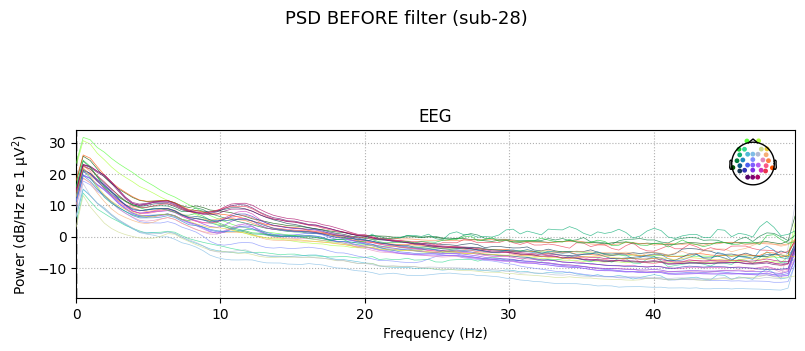

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/var/folders/24/dr50grmd67zfr0yx0df2_1w40000gn/T/ipykernel_611/1754811595.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_psd_after.tight_layout(rect=(0, 0, 1, 0.97))
/var/folders/24/dr50grmd67zfr0yx0df2_1w40000gn/T/ipykernel_611/1754811595.py:29: UserWarning: The figure layout has changed to tight
  fig_psd_after.tight_layout(rect=(0, 0, 1, 0.97))


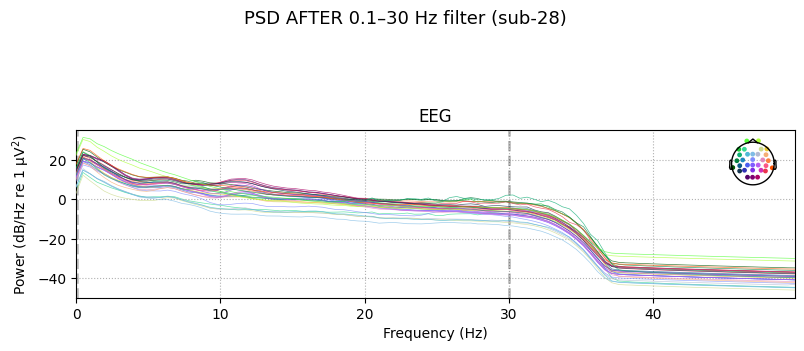


Sanity Check 2: Before (red) vs. after (black) ICA cleaning
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 3 ICA components
    Projecting back using 31 PCA components


/var/folders/24/dr50grmd67zfr0yx0df2_1w40000gn/T/ipykernel_611/1754811595.py:40: UserWarning: The figure layout has changed to tight
  fig_overlay.tight_layout(rect=(0, 0, 1, 0.97))


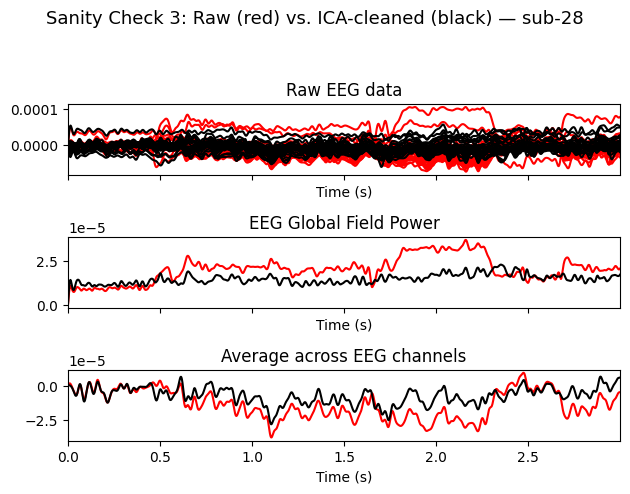

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 3 ICA components
    Projecting back using 31 PCA components


/var/folders/24/dr50grmd67zfr0yx0df2_1w40000gn/T/ipykernel_611/1754811595.py:48: UserWarning: The figure layout has changed to tight
  fig_overlay_eyes.tight_layout(rect=(0, 0, 1, 0.97))


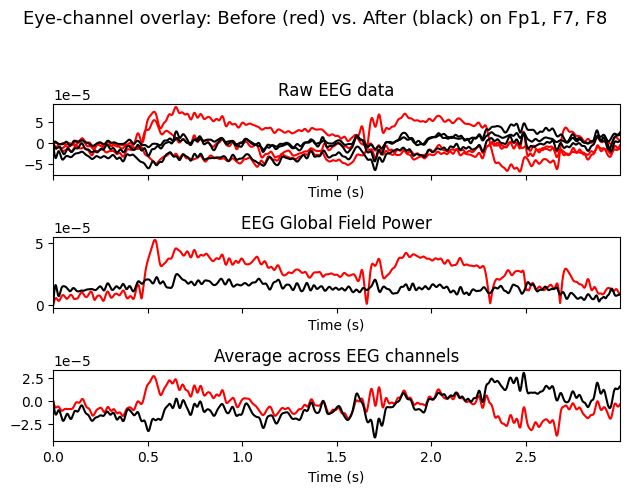


Sanity Check 3: Butterfly ERP plot for Win trials


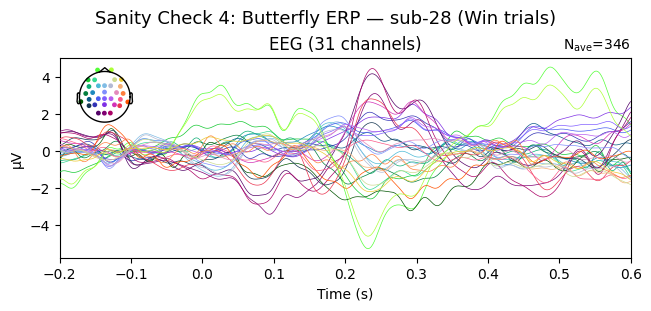


✅ All sanity checks complete.


In [14]:
# ── Sanity check subject ──────────────────────────────────────────────────────

CHECK_SUBJ = "sub-28"
vhdr_path  = BIDS_ROOT / CHECK_SUBJ / "eeg" / f"{CHECK_SUBJ}_task-casinos_eeg.vhdr"
print(f"Running sanity checks on {CHECK_SUBJ}...\n")

# Load and prepare
raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
raw.set_montage(mne.channels.make_standard_montage("standard_1020"), on_missing="ignore")
raw_filtered = raw.copy().filter(l_freq=L_FREQ_ERP, h_freq=H_FREQ, verbose=False)

# ── Sanity Check 1: PSD (before vs after bandpass) ───────────────────────────
# Assumes:
#   raw            -> original unfiltered data
#   raw_filtered   -> 0.1–30 Hz filtered data
#   CHECK_SUBJ     -> subject label string

print("Sanity Check 1: PSD before and after bandpass filtering")

# BEFORE filtering
fig_psd_before = raw.compute_psd(fmax=50).plot(show=False)
fig_psd_before.suptitle(f"PSD BEFORE filter ({CHECK_SUBJ})", fontsize=13, y=1.02)
fig_psd_before.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

# AFTER filtering
fig_psd_after = raw_filtered.compute_psd(fmax=50).plot(show=False)
fig_psd_after.suptitle(f"PSD AFTER 0.1–30 Hz filter ({CHECK_SUBJ})", fontsize=13, y=1.02)
fig_psd_after.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

# ── Sanity Check 2: Raw vs ICA-cleaned ─────────────────────────────
# Red = raw signal; Black = cleaned signal.

print("\nSanity Check 2: Before (red) vs. after (black) ICA cleaning")

# (1) All EEG channels
fig_overlay = ica_check.plot_overlay(raw_filtered, exclude=bad_indices, picks='eeg', show=False)
fig_overlay.suptitle(f"Sanity Check 3: Raw (red) vs. ICA-cleaned (black) — {CHECK_SUBJ}", y=1.02, fontsize=13)
fig_overlay.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

# (2) Eye channels only (Fp1, F7, F8)
fig_overlay_eyes = ica_check.plot_overlay(raw_filtered, exclude=bad_indices,
                                          picks=EOG_PROXY_CHANNELS, show=False)
fig_overlay_eyes.suptitle("Eye-channel overlay: Before (red) vs. After (black) on Fp1, F7, F8",
                          y=1.02, fontsize=13)
fig_overlay_eyes.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()
# ── Sanity Check 3: Single-Subject Butterfly ERP ─────────────────────────────
# Confirms that epochs are correctly time-locked to feedback, baseline-corrected,
# and that the ERP waveforms diverge in the expected 240–340 ms window.
print("\nSanity Check 3: Butterfly ERP plot for Win trials")
raw_clean_check = ica_check.apply(raw_filtered, verbose=False)
raw_clean_check.set_eeg_reference("average", verbose=False)

events_check, event_dict_check = mne.events_from_annotations(raw_clean_check, verbose=False)
target_wins_check = {k: event_dict_check[k] for k in WIN_TRIGGERS if k in event_dict_check}

epochs_check = mne.Epochs(raw_clean_check, events_check, event_id=target_wins_check,
                          tmin=TMIN, tmax=TMAX, baseline=BASELINE, preload=True, verbose=False)
epochs_check.drop_bad(reject=REJECT_UV, verbose=False)
evoked_check = epochs_check.average()

fig_butterfly = evoked_check.plot(spatial_colors=True, show=False)
fig_butterfly.suptitle(f"Sanity Check 4: Butterfly ERP — {CHECK_SUBJ} (Win trials)", fontsize=13)
plt.show()

print("\n✅ All sanity checks complete.")

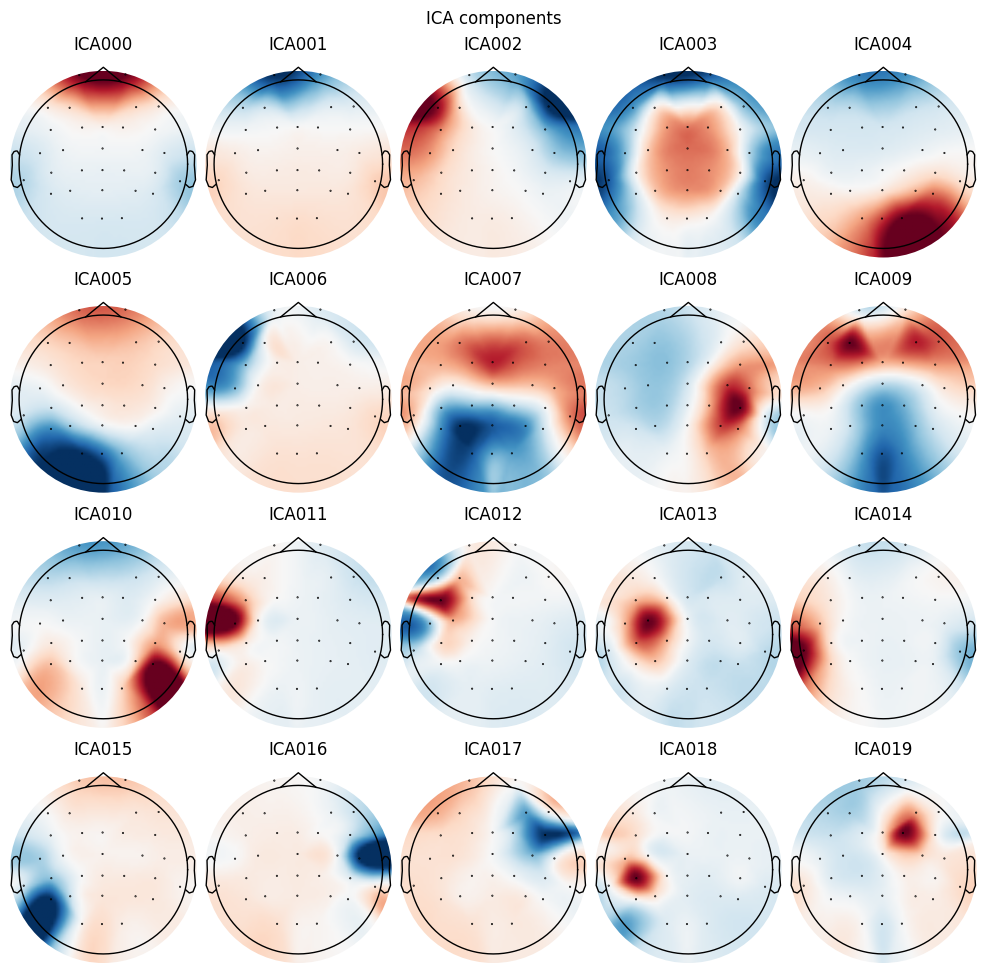

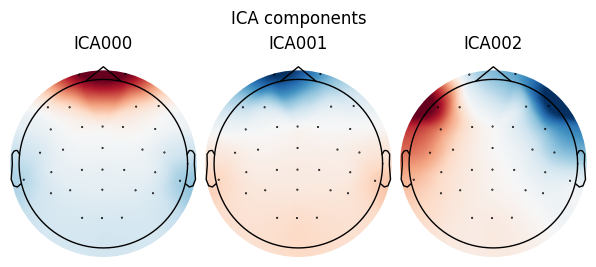

In [13]:
import mne

subj = "sub-28"
vhdr_path = f"{subj}/eeg/{subj}_task-casinos_eeg.vhdr"

# --- Load & prep ---
raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
raw.set_montage(mne.channels.make_standard_montage("standard_1020"), on_missing="ignore")
raw.set_eeg_reference("average", verbose=False)

# ICA copy: 1–30 Hz
raw_ica = raw.copy().filter(l_freq=1.0, h_freq=30.0, verbose=False)

# Fit ICA (20 comps, same as before)
ica = mne.preprocessing.ICA(n_components=20, random_state=42, max_iter="auto")
ica.fit(raw_ica, verbose=False)

# --- Plot ALL components (grid) ---
fig_all = ica.plot_components(picks=None, show=True, contours=0)
# Optional save:
# fig_all.savefig("sub-28_ica_all.png", dpi=150, bbox_inches="tight")

# --- Plot ONLY the blink ICs you identified: 0, 1, 2 ---
fig_blinks = ica.plot_components(picks=[0, 1, 2], show=True, contours=0)
# Optional save:
# fig_blinks.savefig("sub-28_ica_blinks.png", dpi=150, bbox_inches="tight")

---
## Stage 5 — Data Analysis & Visualisation

With preprocessing verified, we move to group-level analysis. This stage is divided into three parts:

- **5A** — Grand average Win vs. Loss ERP comparison, scalp topography, and paired t-test
- **5B** — Contextual (task × cue) analysis: Win/Loss waveforms, difference waves, and subject-level RewP scores
- **5C** — Export of numerical values underlying each figure to CSV for reporting

### Stage 5A (i) — Grand Average Overview: All Feedback Trials Combined

Before separating wins from losses, we first plot the grand average ERP collapsed across both conditions. This gives us an overview of the general feedback-locked response across the group and confirms that the signal is time-locked correctly to feedback onset. Individual subjects are shown as thin grey lines to make inter-subject variance visible — the spread of those lines around the grand average tells us how consistent the RewP is across participants. The highlighted yellow band marks our 240–340 ms analysis window, and the positive deflection visible in that region in the grand average confirms that the pipeline is capturing the expected frontocentral response.

Identifying common channels ...


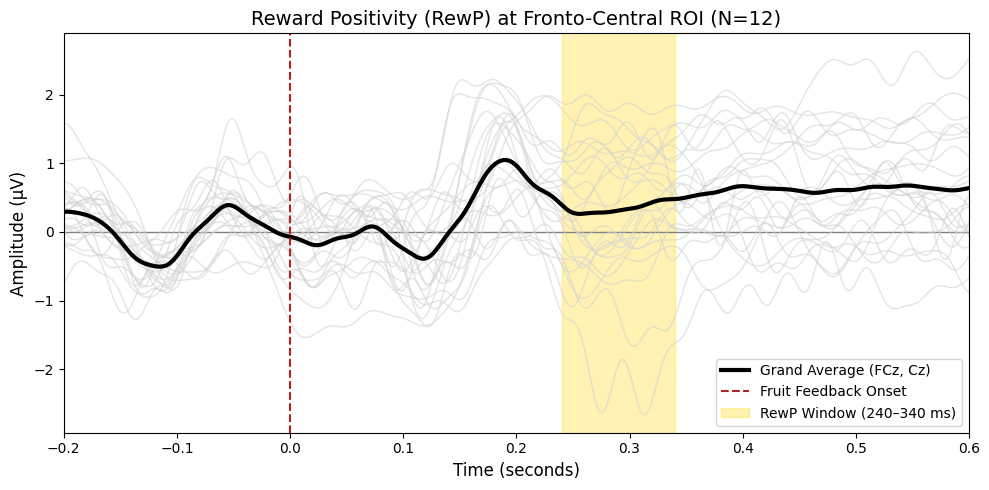

Generating topomap for the RewP window (240–340 ms)...


/var/folders/24/dr50grmd67zfr0yx0df2_1w40000gn/T/ipykernel_611/1192561430.py:51: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig_topo.subplots_adjust(top=0.82)


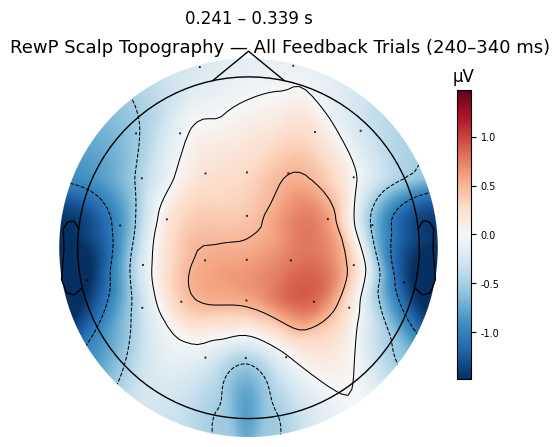

In [7]:
# ── 5A (i): Grand Average — All Feedback Trials Combined ─────────────────────
# We collapse across wins and losses to get a first look at the overall
# feedback-locked response before splitting by condition.

# Combine all subject evokeds (wins + losses together) into one list
all_subject_evokeds = all_wins + all_losses
grand_average = mne.grand_average(all_subject_evokeds)

# Extract ROI indices for the combined grand average
roi_indices_ga = [grand_average.ch_names.index(ch) for ch in ROI_CHANNELS if ch in grand_average.ch_names]
roi_data_ga    = grand_average.data[roi_indices_ga, :].mean(axis=0)

# ── Plot: ERP time-series with individual subject variance ───────────────────
plt.figure(figsize=(10, 5))
plt.axhline(0, color='gray', linewidth=1)

# Individual subjects as thin grey lines — shows human variance across the group
for evk in all_subject_evokeds:
    subj_roi = evk.data[roi_indices_ga, :].mean(axis=0)
    plt.plot(evk.times, subj_roi * 1e6, color='lightgray', alpha=0.6, linewidth=1)

# Grand average on top as a thick black line
plt.plot(grand_average.times, roi_data_ga * 1e6, color='black', linewidth=3,
         label='Grand Average (FCz, Cz)')

plt.axvline(0, color='firebrick', linestyle='--', linewidth=1.5, label='Fruit Feedback Onset')
plt.axvspan(REWP_TMIN, REWP_TMAX, color='gold', alpha=0.3,
            label=f'RewP Window ({int(REWP_TMIN*1000)}–{int(REWP_TMAX*1000)} ms)')

plt.title(f"Reward Positivity (RewP) at Fronto-Central ROI (N={len(valid_subjects)})", fontsize=14)
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Amplitude (µV)", fontsize=12)
plt.xlim([TMIN, TMAX])
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ── Topomap: Scalp distribution at the centre of the RewP window ─────────────
# We plot at 290 ms (midpoint of 240–340 ms) and average ±50 ms around it
# for a stable snapshot of the spatial distribution during the RewP.
print("Generating topomap for the RewP window (240–340 ms)...")
fig_topo = grand_average.plot_topomap(
    times=[0.29],
    average=0.1,
    ch_type='eeg',
    size=3,
    show=False
)
fig_topo.suptitle("RewP Scalp Topography — All Feedback Trials (240–340 ms)",
                  fontsize=13, y=0.90) 
fig_topo.subplots_adjust(top=0.82)     
plt.show()

### Stage 5A (ii) — Win vs. Loss Comparison

Having confirmed the general feedback response above, we now split trials by outcome. Win and loss grand averages are plotted together so that the RewP — the differential positivity for rewarding versus non-rewarding feedback — can be assessed directly. A paired t-test quantifies whether the win/loss amplitude difference within the 240–340 ms window reaches statistical significance across our twelve participants.

Identifying common channels ...
Identifying common channels ...


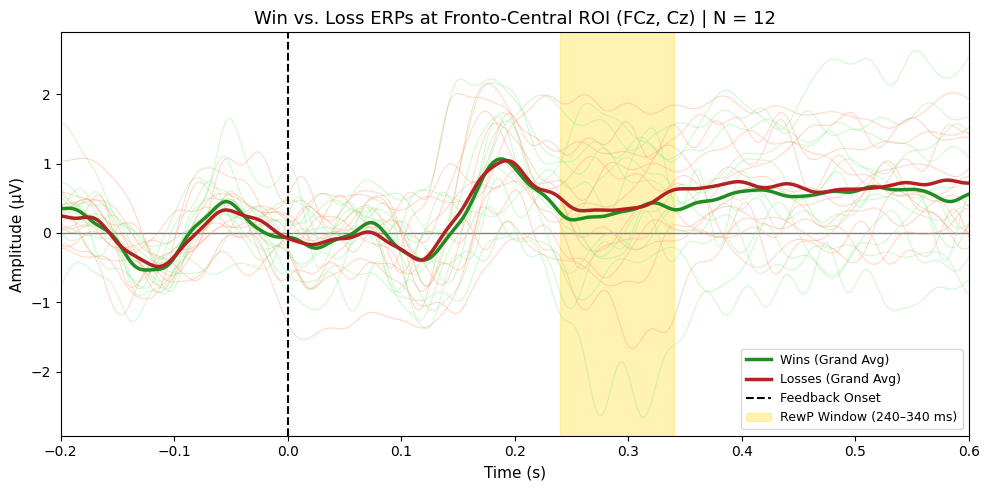

/var/folders/24/dr50grmd67zfr0yx0df2_1w40000gn/T/ipykernel_611/1726415418.py:58: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig_topo.subplots_adjust(top=0.80)       # more headroom; tweak 0.78–0.82 if needed


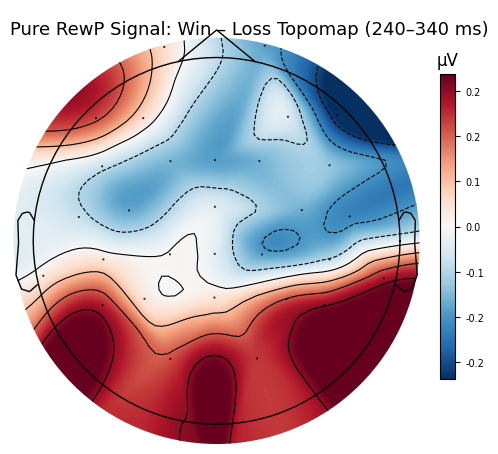

In [8]:
# ── 5A: Grand Average — Win vs. Loss ─────────────────────────────────────────

# Helper: smooth a time-series with a moving average
def smooth(y, sfreq, ms=SMOOTH_MS):
    win = int((ms / 1000) * sfreq)
    if win < 3:
        return y
    return np.convolve(y, np.ones(win) / win, mode="same")

# Grand averages across all valid subjects
grand_win  = mne.grand_average(all_wins)
grand_loss = mne.grand_average(all_losses)
grand_diff = mne.combine_evoked([grand_win, grand_loss], weights=[1, -1])

# Extract ROI indices
roi_indices  = [grand_win.ch_names.index(ch) for ch in ROI_CHANNELS if ch in grand_win.ch_names]
roi_win_data = grand_win.data[roi_indices, :].mean(axis=0)
roi_los_data = grand_loss.data[roi_indices, :].mean(axis=0)

# ── Plot 1: Win vs. Loss ERP at fronto-central ROI ───────────────────────────
plt.figure(figsize=(10, 5))
plt.axhline(0, color='gray', linewidth=1)

# Individual subjects as thin grey lines (illustrates variance)
for evk_w, evk_l in zip(all_wins, all_losses):
    subj_win_roi = evk_w.data[roi_indices, :].mean(axis=0)
    subj_los_roi = evk_l.data[roi_indices, :].mean(axis=0)
    plt.plot(evk_w.times, subj_win_roi * 1e6, color='lightgreen', alpha=0.4, linewidth=0.8)
    plt.plot(evk_l.times, subj_los_roi * 1e6, color='lightsalmon', alpha=0.4, linewidth=0.8)

# Grand averages
plt.plot(grand_win.times,  roi_win_data * 1e6, color='forestgreen', linewidth=2.5, label='Wins (Grand Avg)')
plt.plot(grand_loss.times, roi_los_data * 1e6, color='firebrick',   linewidth=2.5, label='Losses (Grand Avg)')

plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Feedback Onset')
plt.axvspan(REWP_TMIN, REWP_TMAX, color='gold', alpha=0.3, label=f'RewP Window ({int(REWP_TMIN*1000)}–{int(REWP_TMAX*1000)} ms)')

plt.title(f"Win vs. Loss ERPs at Fronto-Central ROI (FCz, Cz) | N = {len(valid_subjects)}", fontsize=13)
plt.xlabel("Time (s)", fontsize=11)
plt.ylabel("Amplitude (µV)", fontsize=11)
plt.xlim([TMIN, TMAX])
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

# ── Plot 2: Difference wave topomap (Win – Loss) ──────────────────────────────
fig_topo = grand_diff.plot_topomap(
    times=[0.29],
    average=0.1,
    ch_type="eeg",
    size=3.2,         # a touch bigger for breathing room
    time_format="",   # remove the 0.241–0.339 label
    show=False
)

fig_topo.suptitle("Pure RewP Signal: Win – Loss Topomap (240–340 ms)",
                  fontsize=13, y=0.90)   # lower the title
fig_topo.subplots_adjust(top=0.80)       # more headroom; tweak 0.78–0.82 if needed
plt.show()

In [9]:
# ── 5A (continued): Statistical Test ─────────────────────────────────────────
# We extract each subject's mean amplitude across the ROI and the RewP time
# window separately for wins and losses, then run a paired t-test.

win_amplitudes  = []
loss_amplitudes = []

for evk_win, evk_loss in zip(all_wins, all_losses):
    win_crop  = evk_win.copy().crop(REWP_TMIN, REWP_TMAX)
    loss_crop = evk_loss.copy().crop(REWP_TMIN, REWP_TMAX)

    win_amp  = win_crop.data[roi_indices, :].mean() * 1e6
    loss_amp = loss_crop.data[roi_indices, :].mean() * 1e6

    win_amplitudes.append(win_amp)
    loss_amplitudes.append(loss_amp)

t_stat, p_value = stats.ttest_rel(win_amplitudes, loss_amplitudes)

print("=" * 52)
print("  STATISTICAL ANALYSIS — PAIRED T-TEST (REWP)")
print("=" * 52)
print(f"  Mean amplitude — Wins:   {np.mean(win_amplitudes):.3f} µV")
print(f"  Mean amplitude — Losses: {np.mean(loss_amplitudes):.3f} µV")
print(f"  RewP effect (Win–Loss):  {np.mean(win_amplitudes) - np.mean(loss_amplitudes):.3f} µV")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value:     {p_value:.4f}")
print()
if p_value < 0.05:
    print("  CONCLUSION: Statistically significant RewP effect (p < 0.05).")
    print("  The brain's feedback response differed significantly between wins and losses.")
else:
    print("  CONCLUSION: Effect did not reach significance (p ≥ 0.05).")
    print("  No significant win/loss difference was detected in this sample.")
print("=" * 52)

  STATISTICAL ANALYSIS — PAIRED T-TEST (REWP)
  Mean amplitude — Wins:   0.300 µV
  Mean amplitude — Losses: 0.393 µV
  RewP effect (Win–Loss):  -0.093 µV
  t-statistic: -0.612
  p-value:     0.5532

  CONCLUSION: Effect did not reach significance (p ≥ 0.05).
  No significant win/loss difference was detected in this sample.


Subjects with contextual evokeds: 12
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...


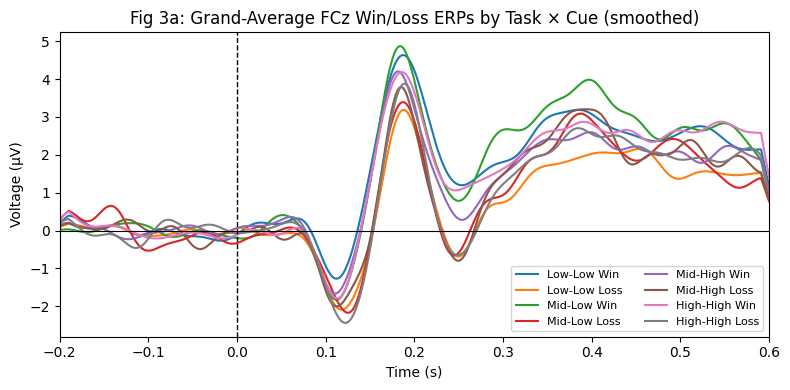

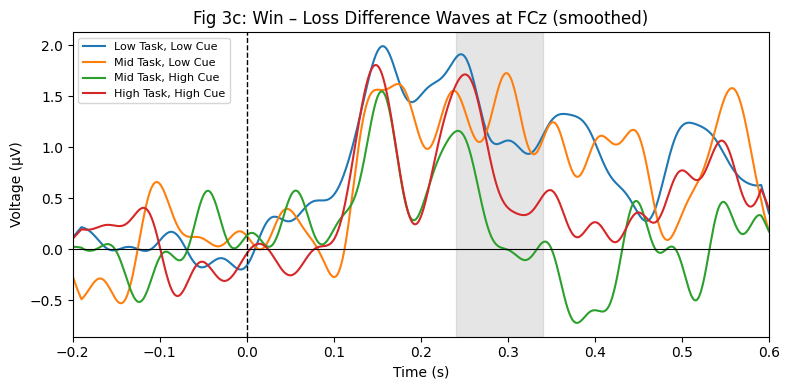

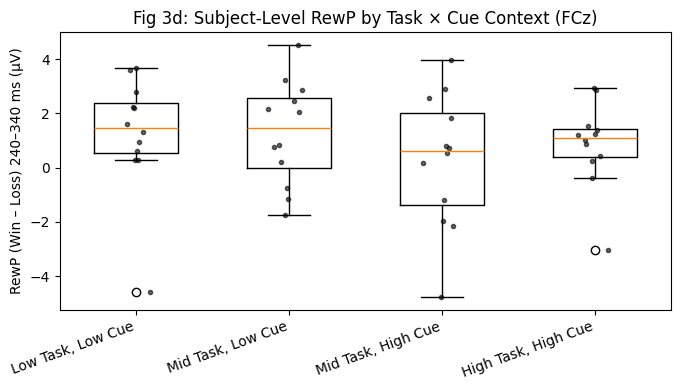

In [10]:
# ── 5B: Contextual Analysis — Win/Loss ERPs by Task × Cue ────────────────────
# This section reprocesses the data using the events.tsv file to access the
# fine-grained condition codes (task level × cue level), which are not captured
# by the simple 20s/30s win/loss trigger scheme used in Stage 3.

subject_evokeds = {}  # {sub: {cond: evoked}}

for sub in subjects:
    vhdr_path   = BIDS_ROOT / sub / "eeg" / f"{sub}_task-casinos_eeg.vhdr"
    events_path = BIDS_ROOT / sub / "eeg" / f"{sub}_task-casinos_events.tsv"

    if not vhdr_path.exists() or not events_path.exists():
        continue

    raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
    raw.filter(l_freq=L_FREQ_ERP, h_freq=20, fir_design="firwin", verbose=False)
    raw.set_eeg_reference("average", verbose=False)

    # Parse events from TSV
    ev_df = pd.read_csv(events_path, sep="\t")
    ev_df = ev_df[ev_df["trial_type"] == "Stimulus"].copy()
    ev_df["code"] = (ev_df["value"].astype(str)
                     .str.replace("S", "", regex=False)
                     .str.strip())
    ev_df["code"]   = pd.to_numeric(ev_df["code"],   errors="coerce")
    ev_df["sample"] = pd.to_numeric(ev_df["sample"], errors="coerce")
    ev_df = ev_df.dropna(subset=["sample", "code"])

    events_arr = np.c_[
        ev_df["sample"].astype(int).values,
        np.zeros(len(ev_df), dtype=int),
        ev_df["code"].astype(int).values
    ]

    present_ids    = set(events_arr[:, 2])
    event_id_sub   = {k: v for k, v in COND_MAP.items() if v in present_ids}
    if not event_id_sub:
        continue

    epochs = mne.Epochs(
        raw, events_arr, event_id=event_id_sub,
        tmin=TMIN, tmax=TMAX, baseline=BASELINE,
        preload=True, on_missing="ignore", verbose=False
    )

    evk_dict = {cond: epochs[cond].average()
                for cond in event_id_sub if len(epochs[cond]) > 0}

    if evk_dict:
        subject_evokeds[sub] = evk_dict

print(f"Subjects with contextual evokeds: {len(subject_evokeds)}")

# ── Grand averages per condition ──────────────────────────────────────────────
grand_ctx = {}
for cond in COND_MAP:
    evks = [ed[cond] for ed in subject_evokeds.values() if cond in ed]
    if evks:
        grand_ctx[cond] = mne.grand_average(evks)

# ── Plot 3: Win/Loss waveforms by task × cue at FCz ──────────────────────────
plt.figure(figsize=(8, 4))
for cond, evk in grand_ctx.items():
    y = evk.copy().pick(["FCz"]).data[0] * 1e6
    y = smooth(y, evk.info["sfreq"])
    plt.plot(evk.times, y, label=cond)

plt.axvline(0, color="k", linestyle="--", linewidth=1)
plt.axhline(0, color="k", linewidth=0.8)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (µV)")
plt.title("Fig 3a: Grand-Average FCz Win/Loss ERPs by Task × Cue (smoothed)")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

# ── Plot 4: Win – Loss difference waves by task × cue ────────────────────────
plt.figure(figsize=(8, 4))
for label, (w, l) in DIFF_PAIRS.items():
    if w in grand_ctx and l in grand_ctx:
        diff = mne.combine_evoked([grand_ctx[w], grand_ctx[l]], weights=[1, -1])
        y = diff.copy().pick(["FCz"]).data[0] * 1e6
        y = smooth(y, diff.info["sfreq"])
        plt.plot(diff.times, y, label=label)

plt.axvspan(REWP_TMIN, REWP_TMAX, color="gray", alpha=0.2)
plt.axvline(0, color="k", linestyle="--", linewidth=1)
plt.axhline(0, color="k", linewidth=0.8)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (µV)")
plt.title("Fig 3c: Win – Loss Difference Waves at FCz (smoothed)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Plot 5: Subject-level RewP scores by context (box + strip) ───────────────
def mean_win_loss(evk_win, evk_loss):
    """Mean RewP amplitude (win – loss) across FCz in the RewP window."""
    w = evk_win.copy().pick(["FCz"]).data
    l = evk_loss.copy().pick(["FCz"]).data
    mask = (evk_win.times >= REWP_TMIN) & (evk_win.times <= REWP_TMAX)
    return (w - l)[:, mask].mean() * 1e6

labels_arr, values_arr = [], []
for sub, evk_dict in subject_evokeds.items():
    for label, (w, l) in DIFF_PAIRS.items():
        if w in evk_dict and l in evk_dict:
            labels_arr.append(label)
            values_arr.append(mean_win_loss(evk_dict[w], evk_dict[l]))

labels_arr = np.array(labels_arr)
values_arr = np.array(values_arr)
unique_labels = list(DIFF_PAIRS.keys())
positions = np.arange(len(unique_labels))

plt.figure(figsize=(7, 4))
box_data = [values_arr[labels_arr == lab] for lab in unique_labels]
plt.boxplot(box_data, positions=positions, widths=0.55)
for i, lab in enumerate(unique_labels):
    y = values_arr[labels_arr == lab]
    x = np.random.normal(positions[i], 0.05, size=len(y))
    plt.plot(x, y, "k.", alpha=0.6)

plt.xticks(positions, unique_labels, rotation=20, ha="right")
plt.ylabel("RewP (Win – Loss) 240–340 ms (µV)")
plt.title("Fig 3d: Subject-Level RewP by Task × Cue Context (FCz)")
plt.tight_layout()
plt.show()

In [11]:
# ── 5C: Export Figure Values to CSV ──────────────────────────────────────────
# We save the numerical data behind each figure so that values can be reported
# precisely in the written report without re-running the full pipeline.

# Fig 3a — Win/Loss waveforms by condition
fig3a_df = pd.DataFrame({"time": list(grand_ctx.values())[0].times})
for cond, evk in grand_ctx.items():
    y = evk.copy().pick(["FCz"]).data[0] * 1e6
    fig3a_df[cond] = smooth(y, evk.info["sfreq"])
fig3a_df.to_csv("fig3a_fcz_values.csv", index=False)
print("Saved → fig3a_fcz_values.csv")

# Fig 3c — Difference waves
fig3c_df = pd.DataFrame({"time": list(grand_ctx.values())[0].times})
for label, (w, l) in DIFF_PAIRS.items():
    if w in grand_ctx and l in grand_ctx:
        diff = mne.combine_evoked([grand_ctx[w], grand_ctx[l]], weights=[1, -1])
        y = diff.copy().pick(["FCz"]).data[0] * 1e6
        fig3c_df[label] = smooth(y, diff.info["sfreq"])
fig3c_df.to_csv("fig3c_fcz_values.csv", index=False)
print("Saved → fig3c_fcz_values.csv")

# Fig 3d — Subject-level RewP scores
rows = []
for sub, evk_dict in subject_evokeds.items():
    for label, (w, l) in DIFF_PAIRS.items():
        if w in evk_dict and l in evk_dict:
            rows.append({"subject": sub, "context": label,
                         "rewp_uv": mean_win_loss(evk_dict[w], evk_dict[l])})
pd.DataFrame(rows).to_csv("fig3d_rewp_values.csv", index=False)
print("Saved → fig3d_rewp_values.csv")

print("\n✅ All outputs exported successfully.")

Saved → fig3a_fcz_values.csv
Saved → fig3c_fcz_values.csv
Saved → fig3d_rewp_values.csv

✅ All outputs exported successfully.
